# 1. Import libraries and dataset

In [93]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from ucimlrepo import fetch_ucirepo
from scipy.stats import randint

# import pipeline components
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# Import metrics cmponents
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)


In [94]:
# Fetch dataset
heart_failure_clinical_records = fetch_ucirepo(id=519)

# Extract features and target
X = heart_failure_clinical_records.data.features
y = heart_failure_clinical_records.data.targets

# Flatten y if it's a DataFrame
y = y.values.ravel() if hasattr(y, 'values') else y

# 2. Split data into training and test sets

In [95]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Create, train and evaluate  machine learning pipelines

In [96]:
# Create logistic regression pipeline
lr_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Create random foresty pipeline
rf_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [97]:
# Train the pipelines
lr_pipeline.fit(X_train, y_train)

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [98]:
# Make predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

y_pred_rf = rf_pipeline.predict(X_test)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Calculate metrics for both pipelines
lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lr)
}

rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf)
}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics
})

print("Model Performance Comparison:")
print(comparison_df.round(2))

Model Performance Comparison:
           Logistic Regression  Random Forest
Accuracy                  0.82           0.83
Precision                 0.90           0.80
Recall                    0.47           0.63
F1-Score                  0.62           0.71
ROC-AUC                   0.85           0.89


# 4. Hyperparameter optimization

## 4.1. Random parameter optimization

In [99]:
# Define parameter distribution for random search 
param_distributions = {
    'classifier__n_estimators': randint(50, 500),
    'classifier__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf': randint(1, 10),
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__bootstrap': [True, False],
    'classifier__class_weight': ['balanced', 'balanced_subsample', None]
}

In [100]:
# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=100,  # Number of parameter combinations to try
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [101]:
# Run RandomizedSearchCV
random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best parameters found:
  classifier__bootstrap: True
  classifier__class_weight: balanced_subsample
  classifier__max_depth: None
  classifier__max_features: sqrt
  classifier__min_samples_leaf: 2
  classifier__min_samples_split: 2
  classifier__n_estimators: 353


In [102]:
# Evaluate on test set
y_pred_rf_random = random_search.predict(X_test)
y_proba_rf_random = random_search.predict_proba(X_test)[:, 1]

test_score_random = roc_auc_score(y_test, y_proba_rf_random)
test_acc_random = accuracy_score(y_test, y_pred_rf_random)

print(f"\nTest Set Performance:")
print(f"  Accuracy: {test_acc_random:.2f}")
print(f"  ROC-AUC:  {test_score_random:.2f}")



Test Set Performance:
  Accuracy: 0.83
  ROC-AUC:  0.90


## 4.2. Exhaustive grid search

In [103]:
# Get the best parameters from random search
best_params = random_search.best_params_

In [104]:
# Create refined parameter grid based on random search results (±10% for numeric params)
# Handle max_depth separately since it can be None
if best_params['classifier__max_depth'] is None:
    max_depth_range = [None, 10, 15, 20]
else:
    lower_depth = max(1, int(best_params['classifier__max_depth'] * 0.9))
    upper_depth = int(best_params['classifier__max_depth'] * 1.1)
    max_depth_range = [
        lower_depth,
        best_params['classifier__max_depth'],
        upper_depth
    ]

# Calculate ±10% ranges for numeric parameters
n_est_lower = max(50, int(best_params['classifier__n_estimators'] * 0.9))
n_est_upper = int(best_params['classifier__n_estimators'] * 1.1)

min_split_lower = max(2, int(best_params['classifier__min_samples_split'] * 0.9))
min_split_upper = int(best_params['classifier__min_samples_split'] * 1.1)

min_leaf_lower = max(1, int(best_params['classifier__min_samples_leaf'] * 0.9))
min_leaf_upper = int(best_params['classifier__min_samples_leaf'] * 1.1)

param_grid = {
    'classifier__n_estimators': [
        n_est_lower,
        best_params['classifier__n_estimators'],
        n_est_upper
    ],
    'classifier__max_depth': max_depth_range,
    'classifier__min_samples_split': [
        min_split_lower,
        best_params['classifier__min_samples_split'],
        min_split_upper
    ],
    'classifier__min_samples_leaf': [
        min_leaf_lower,
        best_params['classifier__min_samples_leaf'],
        min_leaf_upper
    ],
    'classifier__max_features': [best_params['classifier__max_features']],
    'classifier__bootstrap': [best_params['classifier__bootstrap']],
    'classifier__class_weight': [best_params['classifier__class_weight']]
}

# Remove duplicates and clean up
for key in ['classifier__min_samples_split', 'classifier__min_samples_leaf', 'classifier__n_estimators']:
    if key in param_grid:
        param_grid[key] = sorted(list(set(param_grid[key])))

# Handle max_depth separately to deal with None values
if 'classifier__max_depth' in param_grid:
    unique_depths = list(set(param_grid['classifier__max_depth']))
    none_values = [x for x in unique_depths if x is None]
    numeric_values = sorted([x for x in unique_depths if x is not None])
    param_grid['classifier__max_depth'] = none_values + numeric_values

print("\nRefined parameter grid (based on random search results ±10%):")
for param, values in param_grid.items():
    print(f"  {param}: {values}")


Refined parameter grid (based on random search results ±10%):
  classifier__n_estimators: [317, 353, 388]
  classifier__max_depth: [None, 10, 15, 20]
  classifier__min_samples_split: [2]
  classifier__min_samples_leaf: [1, 2]
  classifier__max_features: ['sqrt']
  classifier__bootstrap: [True]
  classifier__class_weight: ['balanced_subsample']


In [105]:
# Setup Grid Search
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters found:
  classifier__bootstrap: True
  classifier__class_weight: balanced_subsample
  classifier__max_depth: 10
  classifier__max_features: sqrt
  classifier__min_samples_leaf: 2
  classifier__min_samples_split: 2
  classifier__n_estimators: 353


In [106]:
# Evaluate on test set
y_pred_rf_grid = grid_search.predict(X_test)
y_proba_rf_grid = grid_search.predict_proba(X_test)[:, 1]

test_score_grid = roc_auc_score(y_test, y_proba_rf_grid)
test_acc_grid = accuracy_score(y_test, y_pred_rf_grid)

print(f"\nTest Set Performance:")
print(f"  Accuracy: {test_acc_grid:.2f}")
print(f"  ROC-AUC:  {test_score_grid:.2f}")



Test Set Performance:
  Accuracy: 0.83
  ROC-AUC:  0.90


In [107]:
# Improvement
print(f"Random Search CV ROC-AUC: {random_search.best_score_:.4f}")
print(f"Grid Search CV ROC-AUC:   {grid_search.best_score_:.4f}")
print(f"Improvement:              {(grid_search.best_score_ - random_search.best_score_):.4f}")
print(f"\nRandom Search Test ROC-AUC: {test_score_random:.4f}")
print(f"Grid Search Test ROC-AUC:   {test_score_grid:.4f}")
print(f"Improvement:                {(test_score_grid - test_score_random):.4f}")

Random Search CV ROC-AUC: 0.9292
Grid Search CV ROC-AUC:   0.9300
Improvement:              0.0008

Random Search Test ROC-AUC: 0.8973
Grid Search Test ROC-AUC:   0.8960
Improvement:                -0.0013


In [108]:
# Evaluate optimized pipeline
y_pred_rf_opt = grid_search.predict(X_test)
y_pred_proba_rf_opt = grid_search.predict_proba(X_test)[:, 1]

rf_opt_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf_opt),
    'Precision': precision_score(y_test, y_pred_rf_opt),
    'Recall': recall_score(y_test, y_pred_rf_opt),
    'F1-Score': f1_score(y_test, y_pred_rf_opt),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf_opt)
}

# Update comparison with optimized model
comparison_df['RF - Optimized'] = rf_opt_metrics

print("Updated Performance Comparison:")
print(comparison_df.round(2))

Updated Performance Comparison:
           Logistic Regression  Random Forest  RF - Optimized
Accuracy                  0.82           0.83            0.83
Precision                 0.90           0.80            0.80
Recall                    0.47           0.63            0.63
F1-Score                  0.62           0.71            0.71
ROC-AUC                   0.85           0.89            0.90


## 4.3. Save the best pipeline

In [109]:
# Save the best pipeline
pipeline_filename = 'heart_failure_pipeline.pkl'
joblib.dump(grid_search.best_estimator_, pipeline_filename)

['heart_failure_pipeline.pkl']

# 5. Load pipeline and use on test data

In [110]:
# Load the saved pipeline
loaded_pipeline = joblib.load(pipeline_filename)

# Choose number of patients to show
number_of_test_patients = 5

# Make predictions on test set (as demonstration)
sample_predictions = loaded_pipeline.predict(X_test[:number_of_test_patients])
sample_probabilities = loaded_pipeline.predict_proba(X_test[:number_of_test_patients])

for i in range(number_of_test_patients):
    print(f"Sample {i+1}:")
    print(f"  Predicted: {'Death Event' if sample_predictions[i] == 1 else 'Survival'}")
    print(f"  Probability: {sample_probabilities[i][1]:.3f}")
    print(f"  Actual: {'Death Event' if y_test[i] == 1 else 'Survival'}")
    print()

Sample 1:
  Predicted: Survival
  Probability: 0.235
  Actual: Survival

Sample 2:
  Predicted: Survival
  Probability: 0.084
  Actual: Survival

Sample 3:
  Predicted: Survival
  Probability: 0.328
  Actual: Survival

Sample 4:
  Predicted: Survival
  Probability: 0.402
  Actual: Survival

Sample 5:
  Predicted: Survival
  Probability: 0.145
  Actual: Survival



# 6. Vizualize model comparison

In [114]:
# Calculate ROC curves for all models
# logistic regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
# Baseline random forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
# Optimized random forest
fpr_rf_opt, tpr_rf_opt, _ = roc_curve(y_test, y_pred_proba_rf_opt)

## 6.2. ROC-curves

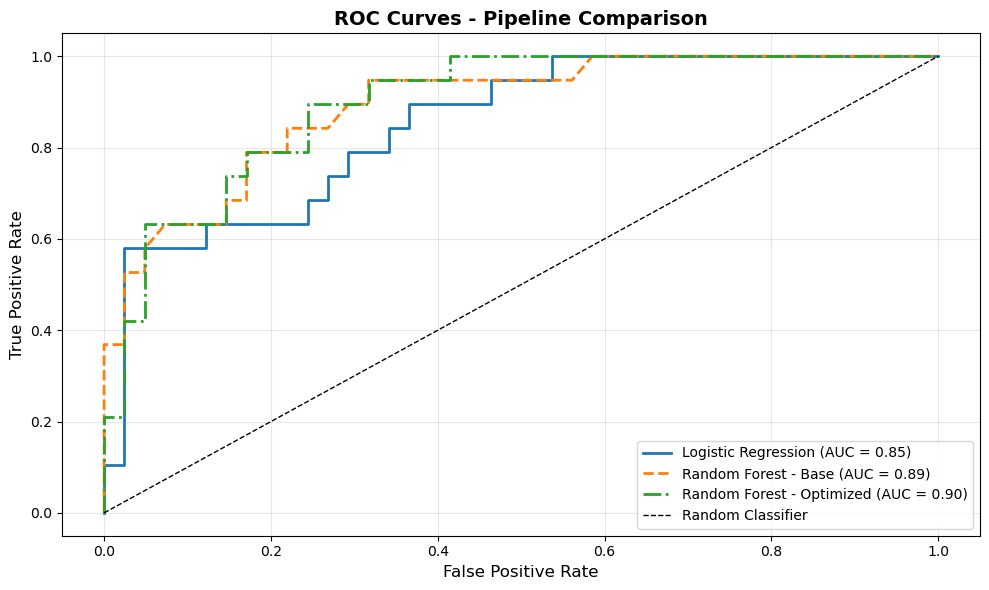

In [115]:
# Plot ROC curves
plt.figure(figsize=(10, 6))

plt.plot(fpr_lr, 
         tpr_lr, 
         label = f'Logistic Regression (AUC = {lr_metrics["ROC-AUC"]:.2f})', 
         linestyle='-', 
         linewidth=2,
        )

plt.plot(fpr_rf,
         tpr_rf,
         label = f'Random Forest - Base (AUC = {rf_metrics["ROC-AUC"]:.2f})',
         linestyle='--',
         linewidth=2,
        )

plt.plot(fpr_rf_opt,
         tpr_rf_opt,
         label = f'Random Forest - Optimized (AUC = {rf_opt_metrics["ROC-AUC"]:.2f})', 
         linestyle='-.',
         linewidth=2,
        )

plt.plot([0, 1],
         [0, 1],
         'k--',
         label='Random Classifier',
         linewidth=1,
        )

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Pipeline Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6.3. Confusion matrix

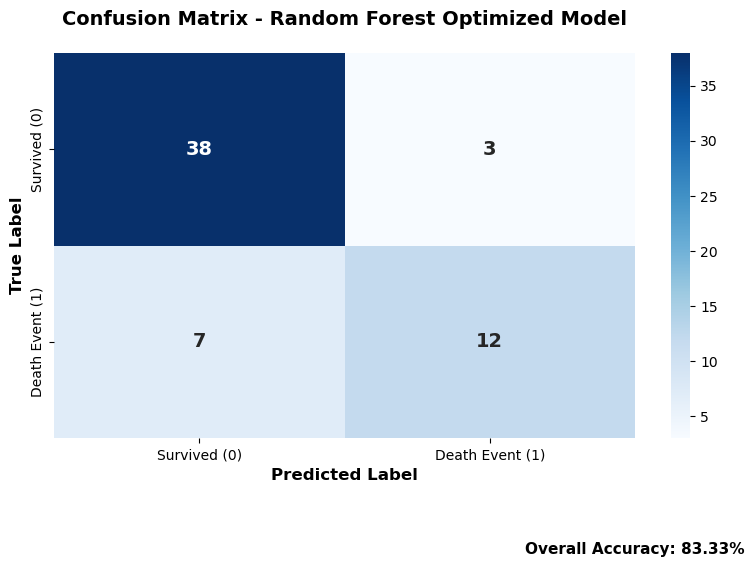


Confusion Matrix Breakdown:
  True Negatives (TN):  38 - Correctly predicted Survival
  False Positives (FP): 3 - Incorrectly predicted Death Event
  False Negatives (FN): 7 - Incorrectly predicted Survival
  True Positives (TP):  12 - Correctly predicted Death Event

Performance Metrics:
  Accuracy:  0.83
  Precision: 0.80
  Recall:    0.63
  F1-Score:  0.71
  ROC-AUC:   0.90


In [116]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf_opt)

# Create visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Survived (0)', 'Death Event (1)'],
            yticklabels=['Survived (0)', 'Death Event (1)'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Confusion Matrix - Random Forest Optimized Model', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Add performance metrics as text
total = cm.sum()
accuracy = (cm[0,0] + cm[1,1]) / total
plt.text(1, -0.3, f'Overall Accuracy: {accuracy:.2%}', 
         ha='center', fontsize=11, fontweight='bold',
         transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

# Print detailed breakdown
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {cm[0,0]} - Correctly predicted Survival")
print(f"  False Positives (FP): {cm[0,1]} - Incorrectly predicted Death Event")
print(f"  False Negatives (FN): {cm[1,0]} - Incorrectly predicted Survival")
print(f"  True Positives (TP):  {cm[1,1]} - Correctly predicted Death Event")

print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {rf_opt_metrics['Accuracy']:.2f}")
print(f"  Precision: {rf_opt_metrics['Precision']:.2f}")
print(f"  Recall:    {rf_opt_metrics['Recall']:.2f}")
print(f"  F1-Score:  {rf_opt_metrics['F1-Score']:.2f}")
print(f"  ROC-AUC:   {rf_opt_metrics['ROC-AUC']:.2f}")

# 7. SHAP

In [117]:
print("\nUsing the Optimized Random Forest pipeline for SHAP analysis...")
print("Extracting the classifier from the pipeline...")

# Extract the trained classifier from the best pipeline
best_classifier = grid_search.best_estimator_.named_steps['classifier']

# Create explainer using TreeExplainer (efficient for tree-based models)
print("Creating TreeExplainer...")
explainer = shap.TreeExplainer(best_classifier)

# Calculate SHAP values for test set
# Note: We need to use the normalized features (after the normalization step)
scaler = grid_search.best_estimator_.named_steps['scaler']
X_test_scaled_for_shap = scaler.transform(X_test)

# Convert to DataFrame with feature names for proper SHAP visualization
X_test_scaled_df = pd.DataFrame(X_test_scaled_for_shap, columns=X_test.columns)

print("Calculating SHAP values for test set...")
shap_values = explainer(X_test_scaled_df)

# For binary classification, use class 1 (death event) SHAP values
shap_values_class1 = shap_values[:, :, 1]


print("✓ SHAP values calculated successfully")
print(f"Base value (expected model output for class 1): {explainer.expected_value[1]:.4f}")

print(f"\nSHAP values shape: {shap_values.values.shape}")
print(f"Using class 1 (death event) SHAP values: {shap_values_class1.values.shape}")


Using the Optimized Random Forest pipeline for SHAP analysis...
Extracting the classifier from the pipeline...
Creating TreeExplainer...
Calculating SHAP values for test set...
✓ SHAP values calculated successfully
Base value (expected model output for class 1): 0.5000

SHAP values shape: (60, 12, 2)
Using class 1 (death event) SHAP values: (60, 12)


## 7.1 Shap beeswarm plot

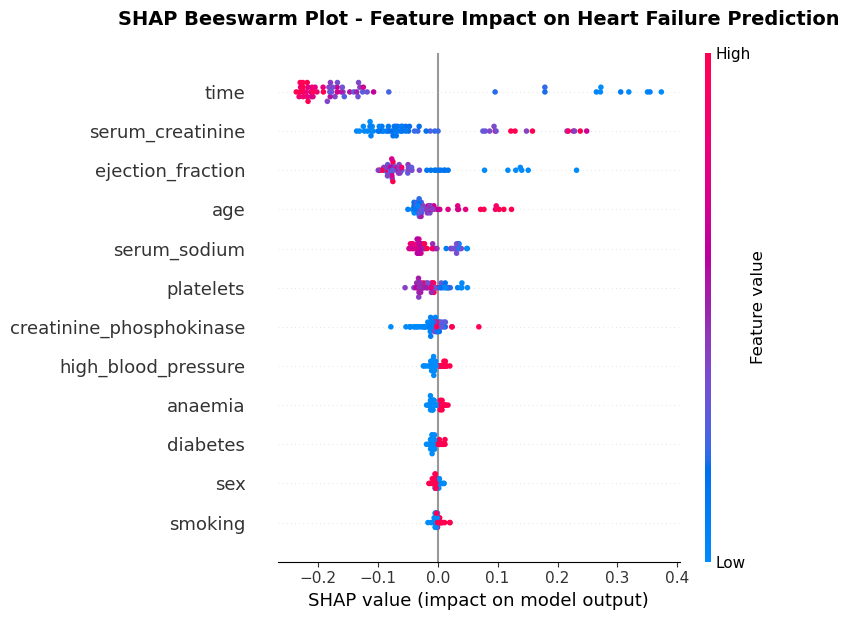

In [118]:
plt.figure(figsize=(12, 8))

shap.plots.beeswarm(shap_values_class1,
                    max_display=12,
                    show=False,
                   )

plt.title('SHAP Beeswarm Plot - Feature Impact on Heart Failure Prediction', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 7.2 SHAP waterfall plot


Analyzing Sample #0:
  Predicted: Survival
  Probability of Death Event: 0.2351
  Actual Outcome: Survival


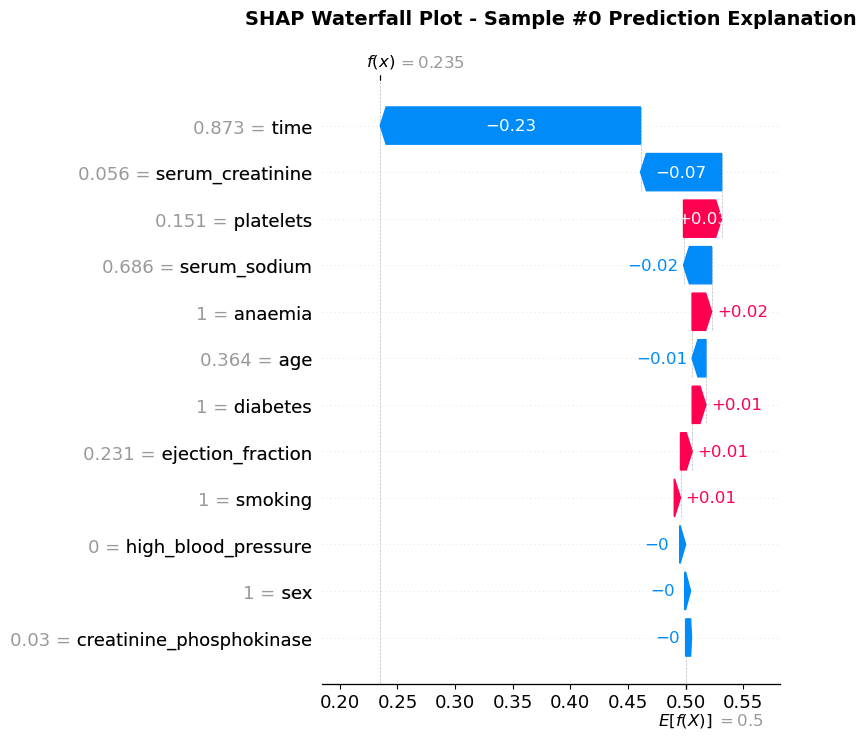

In [120]:
# Select a patient
patient_id = 0  # You can change this to examine different predictions
y_pred_sample = grid_search.predict(X_test[sample_idx:patient_id+1])[0]
y_proba_sample = grid_search.predict_proba(X_test[patient_id:patient_id+1])[0, 1]
y_actual_sample = y_test[patient_id]

print(f"\nAnalyzing Sample #{patient_id}:")
print(f"  Predicted: {'Death Event' if y_pred_sample == 1 else 'Survival'}")
print(f"  Probability of Death Event: {y_proba_sample:.4f}")
print(f"  Actual Outcome: {'Death Event' if y_actual_sample == 1 else 'Survival'}")

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_values_class1[patient_id], max_display=12, show=False)
plt.title(f'SHAP Waterfall Plot - Sample #{patient_id} Prediction Explanation', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()